## call core

In [1]:
import sys
from pathlib import Path

# notebook cwd is the 'notebook/' folder, go up to project root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\Develop\PyTorch_26Project


In [2]:
import torch.nn as nn
from core.models import get_model, get_available_models, MODEL_CONFIGS, _get_feature_dim

# Test model building
if __name__ == "__main__":
    print("=" * 60)
    print("Testing model building")
    print("=" * 60)

    for model_name in get_available_models():
        print(f"\n{model_name}:")
        model = get_model(model_name, num_classes=3)

        config = MODEL_CONFIGS[model_name]
        if config['classifier_name'] == 'classifier':
            classifier = model.classifier
        else:
            classifier = model.fc

        print(f" Classifier: {classifier}")
        print(f" Feature dim: {_get_feature_dim(model, config['classifier_name'])}")
        print(f" Output dim: {classifier[-1].out_features if isinstance(classifier, nn.Sequential) else classifier.out_features}")


d:\Downloads\anaconda3\envs\CHM9360\python.exe
Testing model building

efficientnet_v2_m:
 Classifier: Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)
 Feature dim: 1280
 Output dim: 3

resnext50_32x4d:
 Classifier: Linear(in_features=2048, out_features=3, bias=True)
 Feature dim: 2048
 Output dim: 3

mobilenet_v3_large:
 Classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)
 Feature dim: 1280
 Output dim: 3

densenet161:


KeyboardInterrupt: 

Using GPU: cuda
cuda
Directories created: d:\Develop\PyTorch_26Project\output
Created 5 fold of files

Data loaded successfully!
Samples: 150, Features: 4, Classes: 3
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Shape: (150, 6)

First 5 lines:
   id  sepal_length  sepal_width  petal_length  petal_width  target
0   0           5.1          3.5           1.4          0.2       0
1   1           4.9          3.0           1.4          0.2       0
2   2           4.7          3.2           1.3          0.2       0
3   3           4.6          3.1           1.5          0.2       0
4   4           5.0          3.6           1.4          0.2       0

=== Generating 5-fold TINTO Images ===
Method: tinto
Standardize data: True
--------------------------------------------------

Fold 1/5:
  Training: 120 samples, Validation: 30 samples

Fold 2/5:
  Training: 120 samples, Validation: 30 samples

Fold 3/5:


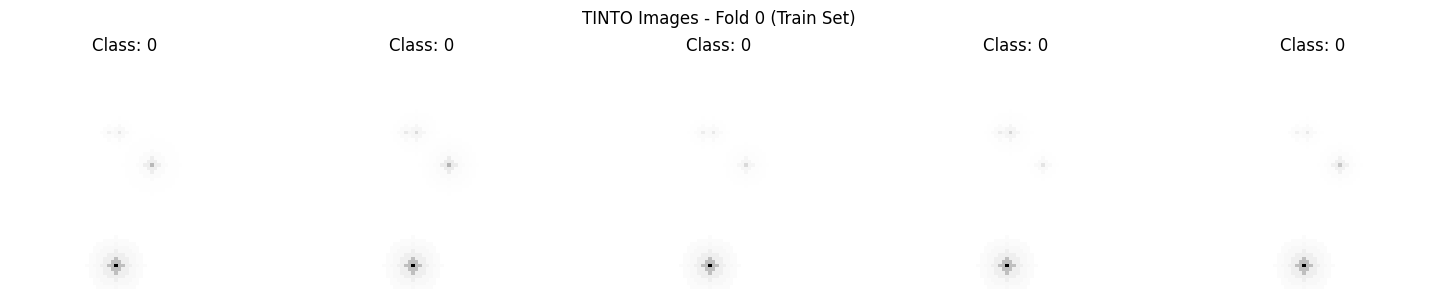


Training: Fold 0, Method: tinto, Model: efficientnet_v2_m

=== Generating 5-fold TINTO Images ===
Method: tinto
Standardize data: True
--------------------------------------------------

Fold 1/5:
  Training: 120 samples, Validation: 30 samples

Fold 2/5:
  Training: 120 samples, Validation: 30 samples

Fold 3/5:
  Training: 120 samples, Validation: 30 samples

Fold 4/5:
  Training: 120 samples, Validation: 30 samples

Fold 5/5:
  Training: 120 samples, Validation: 30 samples

 All 5 folds generated!
DataLoader for Fold 0 created successfully
 - Training batches: 8
 - Validation batches: 2
 - Input size: 224
 - Normalization: Simple
Epoch 1/50 [9.8s] Train Loss: 1.1392, Train Acc: 0.2667 | Val Loss: 1.1005, Val Acc: 0.3333
Epoch 2/50 [9.7s] Train Loss: 1.1139, Train Acc: 0.3333 | Val Loss: 1.1141, Val Acc: 0.3667
Epoch 3/50 [9.7s] Train Loss: 1.0785, Train Acc: 0.4000 | Val Loss: 1.1294, Val Acc: 0.2333
Epoch 4/50 [9.6s] Train Loss: 1.0454, Train Acc: 0.4333 | Val Loss: 1.1052, Val Ac

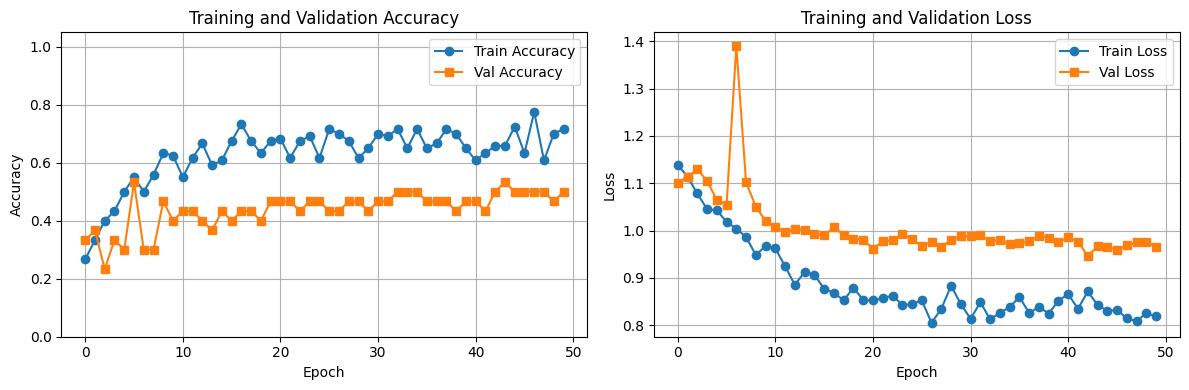

In [7]:
# Main entry point for the TINTO + Transfer Learning project
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 0.Setup
# get the project root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Config: all paths and hyperparameters
from core.config import Config

# Data Loading: load dataset and generate TINTO images
from core.data_loader import load_dataset, create_5fold_tinto_images

# Dataset: PyTorch dataset class and visualization
from core.dataset import visualize_tinto_images

# Models: get model by name
from core.models import get_model, get_available_models

# Trainer: training and evaluating functions
from core.trainer import get_fold_dataloaders, train_transfer_learning

# Traditional: baseline methods (SVM, RF, XGBoost)
from core.traditional import run_all_traditional_methods

# Utils: plotting, results saving, statistical tests
from core.utils import (
    plot_training_curves,
    save_results_to_csv,
    load_results_from_csv,
    perform_wilcoxon_tests,
    print_wilcoxon_summary
)

# Check GPU availability
device = Config.get_device()
print(device)

# Create directories
Config.create_dirs()


# 1.Load data
X, y, feature_names, target_names = load_dataset('iris')


# 2.Generate TINTO images (5-fold CV)
tinto_data = create_5fold_tinto_images(
    X, y,
    method_name=Config.TINTO_METHOD,
    standardize=True,
    feature_names=feature_names
)

# 3.Visualize sample images
visualize_tinto_images(tinto_data['fold_0'], fold_idx=0, num_samples=5)

# 4.Training
# fine_tune_all=False, use_simple_norm=True
history, model, best_acc = train_transfer_learning(
    X, y,
    fold_idx=0,
    method_name=Config.TINTO_METHOD,
    model_name=Config.MODEL_NAME,
    fine_tune_all=False,
    use_simple_norm=True
)

print(f"Best validation accuracy: {best_acc:.4f}")


# 5.Plot training Curves
plot_training_curves(history, save_path=Config.RESULTS_DIR / 'training_curves.png')




In [ ]:
# 6.Compare All models
all_results = []

for model_name in get_available_models():
    print(f"\nTraining: {model_name}")
    history, _, best_acc = train_transfer_learning(
        X, y,
        fold_idx=0,
        method_name=Config.TINTO_METHOD,
        model_name=model_name,
        epochs=20,
        fine_tune_all=False,
        use_simple_norm=True,
        save_model=False
    )
    all_results.append({
        'method': Config.TINTO_METHOD,
        'model': model_name,
        'fold': 0,
        'accuracy': best_acc
    })

print("\n" + "="*60)
print("Model comparison summary")
print("\n" + "="*60)
for r in sorted(all_results, key=lambda x: x['accuracy'], reverse=True):
    print(f"  {r['model']}: {r['accuracy']:.4f}")


# 7.Traditional Methods (baseline)
traditional_results = run_all_traditional_methods(X, y)

import pandas as pd
df_trad = pd.DataFrame(traditional_results)
print("\n" + "="*60)
print("Traditional methods summary")
print("="*60)
summary = df_trad.groupby('model')['accuracy'].agg(['mean', 'std']).round(4)
summary.columns = ['Mean Accuracy', 'Std']
print(summary.sort_values('Mean Accuracy', ascending=False))

# 8.Save all results to csv
detailed_results = []

for r in all_results:
    detailed_results.append({
        'method': r['method'],
        'model': r['model'],
        'fold': r['fold'],
        'accuracy': r['accuracy'],
        'type': 'deep_learning'
    })

for r in traditional_results:
    detailed_results.append({
        'method': r['method'],
        'model': r['model'],
        'fold': r['fold'],
        'accuracy': r['accuracy'],
        'f1_score': r['f1_score'],
        'type': 'traditional'
    })

save_results_to_csv(detailed_results, Config.RESULTS_DIR / 'experiment_results.csv')

# 9.Statistical Test (Wilcoxon)
df = pd.read_csv(Config.RESULTS_DIR / 'experiment_results.csv')

df_dl = df[df['type'] == 'deep_learning']

# compare different methods (>= 2)
if len(df_dl['method'].unique()) >= 2:
    wilcoxon_results = perform_wilcoxon_tests(df_dl, metric='accuracy', group_by='method')
    print_wilcoxon_summary(wilcoxon_results)

# compare different models (same method)
df_tinto = df_dl[df_dl['method'] == Config.TINTO_METHOD]
if len(df_tinto['model'].unique()) >= 2:
    wilcoxon_results = perform_wilcoxon_tests(df_dl, metric='accuracy', group_by='model')
    print_wilcoxon_summary(wilcoxon_results)    


print("\n" + "="*60)
print("Pipeline completed successfully!")
print(f"Results saved to: {Config.RESULTS_DIR}")
print("="*60)